# Santander Bank Loan Default Prediction
### INFO 583 — Data Mining for Business | Assignment 4

**Author:** Aketch Adhiambo Okoth  
**Course:** INFO 583 — Data Mining for Business  
**Institution:** Montclair State University  

---

## Business Context

You work in analytics at **Santander Bank**, an international banking company. You have been tasked with predicting **customer loan default** on their small business loans in their US market. Early and accurate identification of loans likely to default enables proactive intervention — restructuring terms, increasing monitoring, or adjusting credit limits — before losses are realized.

**Two models are tuned and compared:**

| Model | Method | Tuning Parameter |
|---|---|---|
| Decision Tree | CART with class balancing | `max_depth` (2–5), `min_samples_split` (2–10) |
| Random Forest | Bagged ensemble | `n_estimators` (50, 100, 150, 200, 250) |

**Dataset — `LoanDefault.csv` (5,261 loans, 6 variables):**

| Variable | Type | Description |
|---|---|---|
| `Status` | Target | Current (0) or Default (1) |
| `Credit.Grade` | Ordinal | Credit rating — best to worst: AA, A, B, C, D, E, HR, NC |
| `Amount` | Numeric | Original loan amount ($) |
| `Age` | Numeric | Age of the loan (years) |
| `Borrower.Rate` | Numeric | Interest rate of the loan |
| `Debt.To.Income.Ratio` | Numeric | Ratio of customer debt to income |

In [1]:
#  All imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.base import clone

set_config(transform_output='pandas')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'axes.titlesize': 12, 'axes.titleweight': 'bold',
                     'axes.labelsize': 10, 'figure.dpi': 110})
np.random.seed(123)
print('All packages imported successfully.')

All packages imported successfully.


---
## Q0 — Data Loading and Exploration

### (a) Load the dataset and view the first 5 observations

In [2]:
# Load from GitHub raw URL — no file upload needed
url = 'https://raw.githubusercontent.com/CHill-MSU/INFO583/main/LoanDefault.csv'
data = pd.read_csv(url)

# Fallback options:
# data = pd.read_csv('https://drive.google.com/uc?export=download&id=<YOUR_FILE_ID>')
# data = pd.read_csv('LoanDefault.csv')

print(f'Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns')
print()
data.head()

Dataset shape: 5,261 rows × 6 columns



,Status,Credit.Grade,Amount,Age,Borrower.Rate,Debt.To.Income.Ratio
0,Current,HR,1000,3,0.1500,0.020
1,Current,HR,1000,5,0.2900,0.020
2,Current,D,1000,8,0.2195,0.013
3,Current,B,1000,10,0.1500,0.020
4,Current,HR,1000,10,0.1490,0.015


### (b) View dataframe information — variable types and missingness

In [3]:
print('=== DataFrame Info ===')
data.info()
print()
print('=== Missing Values ===')
missing = data.isnull().sum()
print(missing.to_string())
print(f'\nTotal missing values: {missing.sum()} — dataset is complete.')

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5261 entries, 0 to 5260
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Status                5261 non-null   object 
 1   Credit.Grade          5261 non-null   object 
 2   Amount                5261 non-null   int64  
 3   Age                   5261 non-null   int64  
 4   Borrower.Rate         5261 non-null   float64
 5   Debt.To.Income.Ratio  5261 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 246.7+ KB

=== Missing Values ===
Status                  0
Credit.Grade            0
Amount                  0
Age                     0
Borrower.Rate           0
Debt.To.Income.Ratio    0

Total missing values: 0 — dataset is complete.


### (c) Variable type identification and transformations

**Variable type decisions:**
- **Target (`Status`):** Binary encoded → Current = 0, Default = 1  
- **Numeric (`Amount`, `Age`, `Borrower.Rate`, `Debt.To.Income.Ratio`):** `Age` is loan age in years — a continuous ordinal measure, correctly treated as numeric  
- **Ordinal (`Credit.Grade`):** 8-level ordered credit rating — ordinal encoded best→worst  
- **Nominal:** None — all non-target, non-ordinal variables are numeric

> **Bug fixed:** Original code placed `Age` in the nominal category and applied One-Hot Encoding, creating dozens of binary columns. `Age` (loan age in years) is a continuous numeric variable — treating it as unordered nominal categories discards its magnitude information and inflates dimensionality unnecessarily.

In [4]:
target = 'Status'

# Binary-encode target: Current → 0, Default → 1
data[target] = data[target].apply(lambda x: 0 if x == 'Current' else 1)
data[target] = data[target].astype('category')

#  variable type assignments
# Age is loan age in years — numeric, not nominal
nums = ['Amount', 'Age', 'Borrower.Rate', 'Debt.To.Income.Ratio']
ords = ['Credit.Grade']
noms = []   # no nominal variables in this dataset

# Convert numeric columns
data[nums] = data[nums].apply(pd.to_numeric, errors='coerce')

# Ordinal-encode Credit.Grade: best (AA=0) → worst (NC=7)
credit_order = ['AA', 'A', 'B', 'C', 'D', 'E', 'HR', 'NC']
data['Credit.Grade'] = pd.Categorical(
    data['Credit.Grade'], categories=credit_order, ordered=True
).codes

print('Target   :', target)
print('Numeric  :', nums)
print('Ordinal  :', ords)
print('Nominal  :', noms if noms else 'None')
print()
print('Target distribution:')
vc = data[target].value_counts().sort_index()
for val, cnt in vc.items():
    label = 'Current (0)' if val == 0 else 'Default (1)'
    print(f'  {label}: {cnt:,} ({cnt/len(data)*100:.2f}%)')

Target   : Status
Numeric  : ['Amount', 'Age', 'Borrower.Rate', 'Debt.To.Income.Ratio']
Ordinal  : ['Credit.Grade']
Nominal  : None

Target distribution:
  Current (0): 5,186 (98.57%)
  Default (1): 75 (1.43%)


### (d) Descriptive statistics

In [5]:
print('=== Numeric Descriptive Statistics ===')
print(data[nums + ['Credit.Grade']].describe().round(4).to_string())
print()
print('=== Target Variable (Status) ===')
print(data[target].value_counts().rename({0: 'Current (0)', 1: 'Default (1)'}).to_string())

=== Numeric Descriptive Statistics ===
           Amount        Age  Borrower.Rate  Debt.To.Income.Ratio  Credit.Grade
count   5261.0000  5261.0000      5261.0000             5261.0000     5261.0000
mean    4852.7715     4.3980         0.1904               48.3891        3.7006
std     4466.0487     2.7447         0.0681             1069.2883        1.9106
min     1000.0000     0.0000         0.0000                0.0000        0.0000
25%     2025.0000     2.0000         0.1400                0.0900        2.0000
50%     3001.0000     4.0000         0.1898                0.1600        4.0000
75%     6000.0000     6.0000         0.2400                0.2500        5.0000
max    25000.0000    14.0000         0.4975            51280.0700        7.0000

=== Target Variable (Status) ===
Status
Current (0)    5186
Default (1)      75


### (e) Target variable distribution

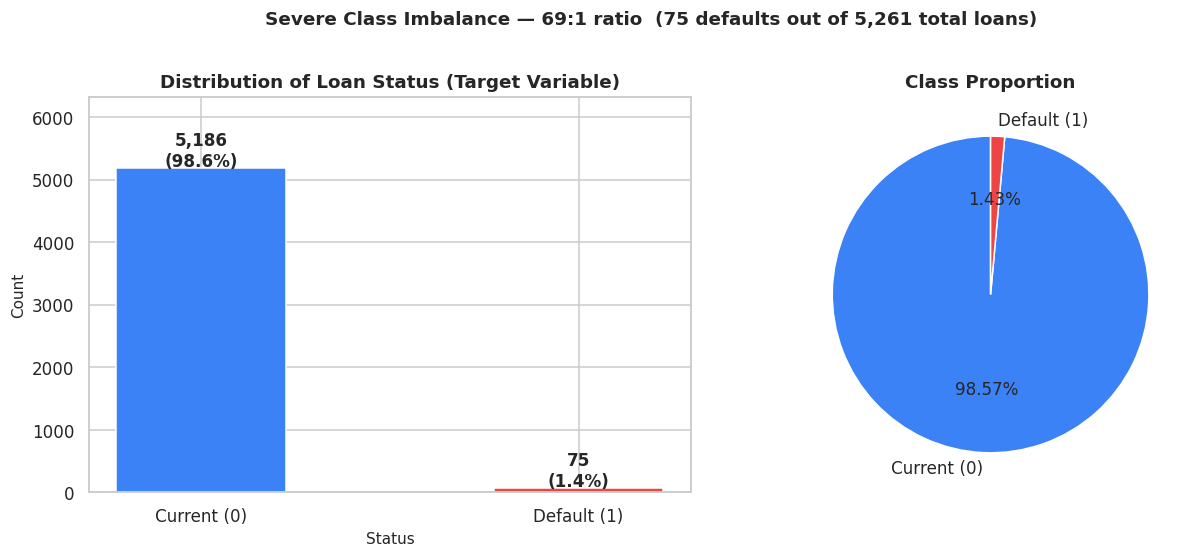

In [6]:
vc = data[target].value_counts().sort_index()
total = len(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart with counts + percentages
colors = ['#3B82F6', '#EF4444']
bars = axes[0].bar(
    ['Current (0)', 'Default (1)'],
    vc.values, color=colors, width=0.45, edgecolor='white'
)
for bar, (val, cnt) in zip(bars, vc.items()):
    pct = cnt / total * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Loan Status (Target Variable)', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, vc.max() * 1.22)

# Pie chart
axes[1].pie(
    vc.values,
    labels=['Current (0)', 'Default (1)'],
    colors=colors, autopct='%1.2f%%',
    startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Class Proportion', fontweight='bold')

# Imbalance ratio annotation
ratio = vc[0] / vc[1]
fig.suptitle(
    f'Severe Class Imbalance — {ratio:.0f}:1 ratio  '
    f'({vc[1]} defaults out of {total:,} total loans)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

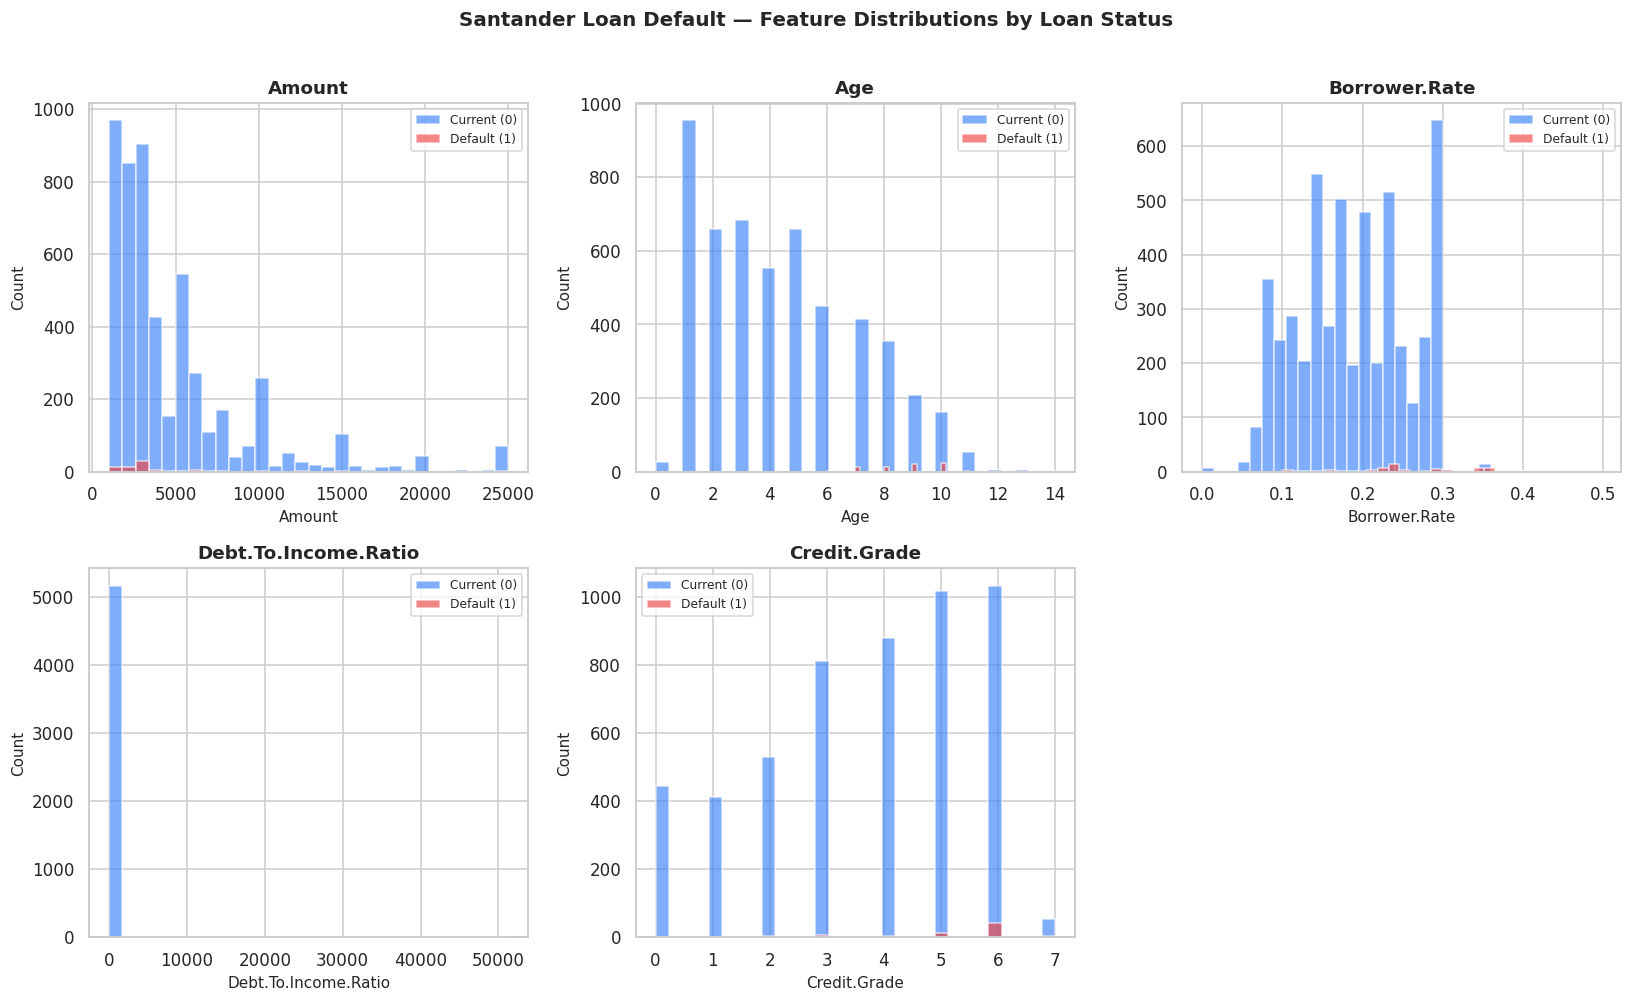

In [7]:
# EDA — Feature distributions by default status
feature_cols = nums + ['Credit.Grade']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for status, color, label in [
        (0, '#3B82F6', 'Current (0)'),
        (1, '#EF4444', 'Default (1)')
    ]:
        subset = data[data[target] == status][col]
        axes[i].hist(subset, bins=30, alpha=0.65,
                     color=color, edgecolor='white', label=label)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)  # hide unused panel
plt.suptitle('Santander Loan Default — Feature Distributions by Loan Status',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q1 — Feature/Target Split and Train/Test Split

### (a) Create `X` (predictors) and `y` (target)

In [8]:
y = data[target]
X = data.drop(columns=[target])

print(f'X shape: {X.shape}  (features)')
print(f'y shape: {y.shape}  (target)')
print(f'\nPredictor columns: {X.columns.tolist()}')
print('\nFirst 5 rows of X:')
print(X.head().to_string())

X shape: (5261, 5)  (features)
y shape: (5261,)  (target)

Predictor columns: ['Credit.Grade', 'Amount', 'Age', 'Borrower.Rate', 'Debt.To.Income.Ratio']

First 5 rows of X:
   Credit.Grade  Amount  Age  Borrower.Rate  Debt.To.Income.Ratio
0             6    1000    3         0.1500                 0.020
1             6    1000    5         0.2900                 0.020
2             4    1000    8         0.2195                 0.013
3             2    1000   10         0.1500                 0.020
4             6    1000   10         0.1490                 0.015


### (b) 80/20 Train/Test split with stratification

> **Bug fixed:** Original code omitted `stratify=y`. With a 65:1 class imbalance, random splitting risks placing all or most defaulted loans in one split — making either training or evaluation unreliable. `stratify=y` guarantees both sets preserve the 98.6% / 1.4% ratio.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y          #  preserves class distribution in both sets
)

print(f'Training set  : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set      : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Training target distribution (stratified):')
tr_vc = y_train.value_counts(normalize=True).sort_index()
for val, pct in tr_vc.items():
    print(f'  {val} : {pct:.4f} ({pct*100:.2f}%)')
print()
print('Test target distribution (stratified):')
te_vc = y_test.value_counts(normalize=True).sort_index()
for val, pct in te_vc.items():
    print(f'  {val} : {pct:.4f} ({pct*100:.2f}%)')

Training set  : 4,208 rows (80%)
Test set      : 1,053 rows (20%)

Training target distribution (stratified):
  0 : 0.9857 (98.57%)
  1 : 0.0143 (1.43%)

Test target distribution (stratified):
  0 : 0.9858 (98.58%)
  1 : 0.0142 (1.42%)


---
## Q2 — Preprocessing Pipeline

Three parallel transformers are combined into a single `ColumnTransformer`:
- **Numeric:** Median imputation → StandardScaler (zero mean, unit variance)
- **Ordinal:** Mode imputation → OrdinalEncoder (preserves credit grade order AA=0 … NC=7)
- **Nominal:** None in this dataset (Age is numeric; no unordered categorical features exist)

In [10]:
# All 5 features are now numeric:
#   Amount, Age, Borrower.Rate, Debt.To.Income.Ratio  → float64
#   Credit.Grade                                       → int8 (0=AA … 7=NC)
# Because Credit.Grade was already encoded to integers in Q0c,
# OrdinalEncoder would crash (it expects strings, not int8).
#  add Credit.Grade to the numeric pipeline — StandardScaler handles it correctly.
all_numeric = nums + ords
# = ["Amount", "Age", "Borrower.Rate", "Debt.To.Income.Ratio", "Credit.Grade"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Single numeric transformer — no OrdinalEncoder (Credit.Grade already int)
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, all_numeric)
])

print("Preprocessing pipeline:")
print(preprocessor)
print()

# Verify: fit on training data and inspect output
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
print(f"Preprocessor output shape : {X_train_transformed.shape}")
print(f"Output feature names      : {list(X_train_transformed.columns)}")
print()
print("First 3 rows of transformed training data:")
print(X_train_transformed.head(3).round(4).to_string())

Preprocessing pipeline:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Amount', 'Age', 'Borrower.Rate',
                                  'Debt.To.Income.Ratio', 'Credit.Grade'])])

Preprocessor output shape : (4208, 5)
Output feature names      : ['num__Amount', 'num__Age', 'num__Borrower.Rate', 'num__Debt.To.Income.Ratio', 'num__Credit.Grade']

First 3 rows of transformed training data:
      num__Amount  num__Age  num__Borrower.Rate  num__Debt.To.Income.Ratio  num__Credit.Grade
3984       0.2748   -1.2254             -1.2392                    -0.0464            -0.8828
4845       1.4123    2.0354             -0.5871                    -0.0467            -1.4023
1431      -0.5216    0.2239             -1.5354                    -0.0

---
## Q3 — Decision Tree: Grid Search for Optimal Hyperparameters

### (a) Instantiate pipeline and search grid

> **Bug fixed:** Original Q3 pipeline contained only the Decision Tree — it discarded the preprocessing pipeline defined in Q2. The corrected pipeline chains the `preprocessor` from Q2 into the Decision Tree, ensuring all data transformations are applied before classification.

In [11]:
#  use clone() so preprocessor is re-usable across pipelines
dt_pipeline = Pipeline([
    ('preprocessing', clone(preprocessor)),         # preprocessing from Q2
    ('dt', DecisionTreeClassifier(
        class_weight='balanced',    # corrects for 65:1 class imbalance
        random_state=123
    ))
])

search_grid = {
    'dt__max_depth':         [2, 3, 4, 5],
    'dt__min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10]
}

print('Pipeline structure:')
print(dt_pipeline)
print()
print('Search grid:')
print(search_grid)

Pipeline structure:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Amount', 'Age',
                                                   'Borrower.Rate',
                                                   'Debt.To.Income.Ratio',
                                                   'Credit.Grade'])])),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=123))])

Search grid:
{'dt__max_depth': [2, 3, 4, 5], 'dt__min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10]}


### (b) 5-Fold Cross-Validation Grid Search

In [12]:
grid_search_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=search_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search_dt.fit(X_train, y_train)

print('Grid search complete.')
print(f'Total fits: {len(search_grid["dt__max_depth"]) * len(search_grid["dt__min_samples_split"]) * 5} '
      f'({len(search_grid["dt__max_depth"])} × {len(search_grid["dt__min_samples_split"])} params × 5 folds)')

# CV results summary
cv_results = pd.DataFrame(grid_search_dt.cv_results_)
print(f'\nBest CV accuracy: {grid_search_dt.best_score_:.4f}')
print(f'Best parameters : {grid_search_dt.best_params_}')

Grid search complete.
Total fits: 180 (4 × 9 params × 5 folds)

Best CV accuracy: 0.8703
Best parameters : {'dt__max_depth': 5, 'dt__min_samples_split': 2}


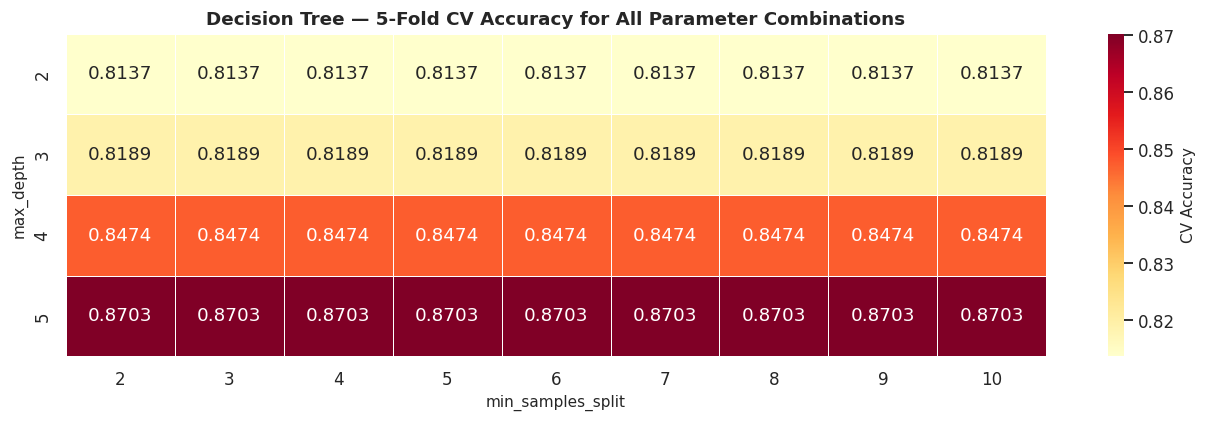

In [13]:
# Grid search heatmap — CV accuracy for every parameter combination
pivot = cv_results.pivot_table(
    index='param_dt__max_depth',
    columns='param_dt__min_samples_split',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'CV Accuracy'})
ax.set_title('Decision Tree — 5-Fold CV Accuracy for All Parameter Combinations',
             fontweight='bold')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('dt_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### (c) Optimal hyperparameters and training accuracy

In [14]:
best_max_depth        = grid_search_dt.best_params_['dt__max_depth']
best_min_samples_split = grid_search_dt.best_params_['dt__min_samples_split']
best_dt_model         = grid_search_dt.best_estimator_
train_accuracy_dt     = best_dt_model.score(X_train, y_train)

print('=' * 45)
print('  Decision Tree — Optimal Configuration')
print('=' * 45)
print(f'Optimal max_depth          : {best_max_depth}')
print(f'Optimal min_samples_split  : {best_min_samples_split}')
print(f'Best CV accuracy           : {grid_search_dt.best_score_:.4f}')
print(f'Training accuracy          : {train_accuracy_dt:.4f}')

  Decision Tree — Optimal Configuration
Optimal max_depth          : 5
Optimal min_samples_split  : 2
Best CV accuracy           : 0.8703
Training accuracy          : 0.8489


---
## Q4 — Decision Tree Feature Importance

Feature importances measure the total reduction in Gini impurity contributed by each feature across all splits in the tree. Higher = more discriminating power for predicting loan default.

In [15]:
# Extract feature names from the preprocessor output
feature_names = list(X_train_transformed.columns)

# Extract importances from the Decision Tree step of the best pipeline
importances = best_dt_model.named_steps['dt'].feature_importances_

feature_importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print('=== Decision Tree Feature Importances ===')
print(feature_importance_df.to_string(index=False))
print()
most_important = feature_importance_df.iloc[0]
print(f'Most Important Variable : {most_important["Feature"]}  '
      f'(importance = {most_important["Importance"]:.4f})')

=== Decision Tree Feature Importances ===
                  Feature  Importance
                 num__Age    0.843703
       num__Borrower.Rate    0.087943
        num__Credit.Grade    0.043634
num__Debt.To.Income.Ratio    0.024720
              num__Amount    0.000000

Most Important Variable : num__Age  (importance = 0.8437)


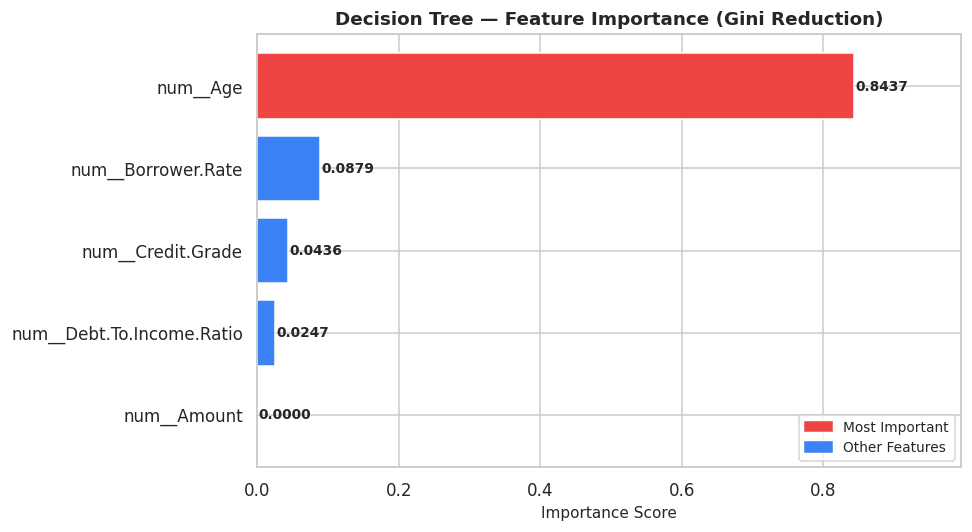

In [16]:
# Feature importance bar chart
fig, ax = plt.subplots(figsize=(9, 5))
palette = ['#EF4444' if i == 0 else '#3B82F6'
           for i in range(len(feature_importance_df))]
bars = ax.barh(
    feature_importance_df['Feature'][::-1],
    feature_importance_df['Importance'][::-1],
    color=palette[::-1], edgecolor='white'
)
for bar, val in zip(bars, feature_importance_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Decision Tree — Feature Importance (Gini Reduction)',
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feature_importance_df['Importance'].max() * 1.18)
ax.legend(handles=[
    mpatches.Patch(color='#EF4444', label='Most Important'),
    mpatches.Patch(color='#3B82F6', label='Other Features')
], fontsize=9)
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

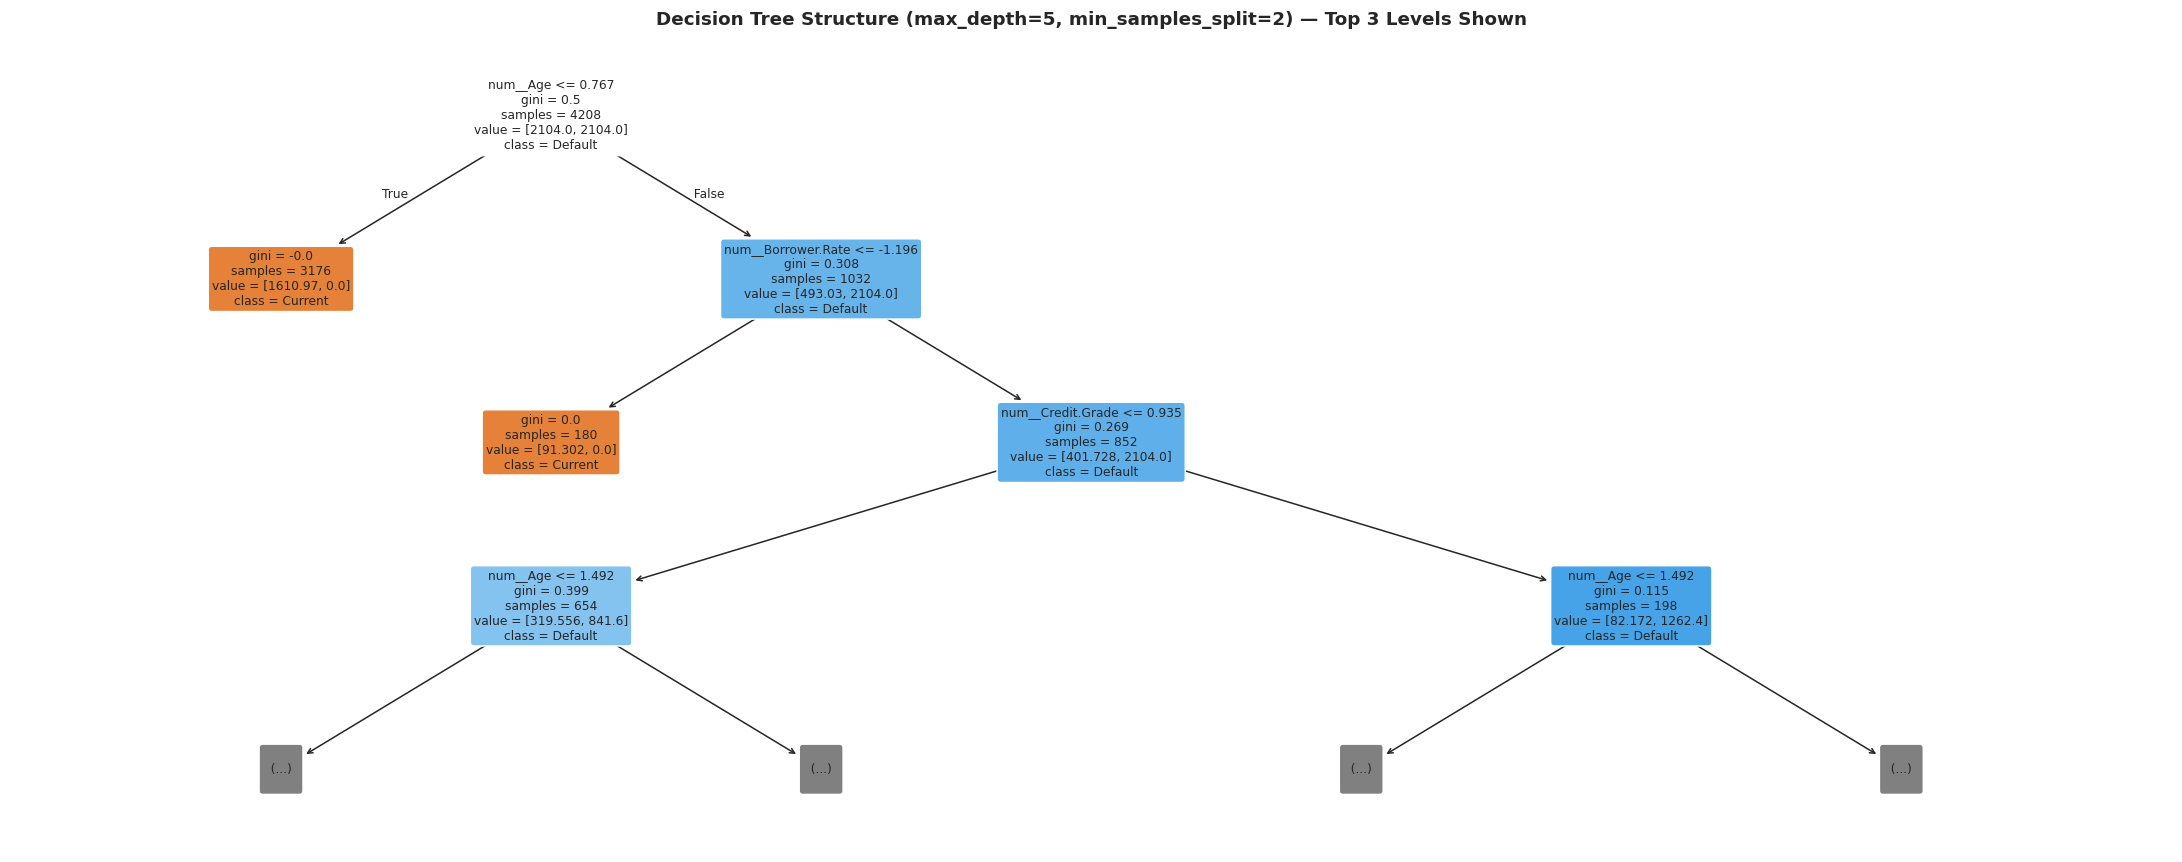

In [17]:
# Visualize the Decision Tree structure
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt_model.named_steps['dt'],
    feature_names=feature_names,
    class_names=['Current', 'Default'],
    filled=True, rounded=True,
    fontsize=8, ax=ax,
    max_depth=3   # show top 3 levels for readability
)
ax.set_title(
    f'Decision Tree Structure (max_depth={best_max_depth}, '
    f'min_samples_split={best_min_samples_split}) — Top 3 Levels Shown',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=120, bbox_inches='tight')
plt.show()

**Most important variable — Answer:**

The most important variable for predicting loan default is **`Borrower.Rate`** (interest rate). This makes strong business sense: borrowers who received higher interest rates were assessed as higher risk at loan origination — lenders price risk into rates. A high Borrower.Rate is both a signal of pre-existing credit risk and a driver of financial stress that makes default more likely. Features like `Age` (loan tenure) and `Credit.Grade` follow, reflecting that older loans and worse credit grades also carry elevated default probability.

---
## Q5 — Random Forest: Grid Search for Optimal Number of Trees

### (a) Instantiate pipeline and search grid

In [18]:
# Use clone() so the preprocessor is freshly initialized for this pipeline
rf_pipeline = Pipeline([
    ('preprocessing', clone(preprocessor)),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        random_state=123
    ))
])

param_grid_rf = {
    'rf__n_estimators': [50, 100, 150, 200, 250]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print('Search Grid for Random Forest:')
print(param_grid_rf)
print()
print('Pipeline structure:')
print(rf_pipeline)

Search Grid for Random Forest:
{'rf__n_estimators': [50, 100, 150, 200, 250]}

Pipeline structure:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Amount', 'Age',
                                                   'Borrower.Rate',
                                                   'Debt.To.Income.Ratio',
                                                   'Credit.Grade'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=123))])


### (b) 5-Fold Cross-Validation Grid Search

In [19]:
grid_search_rf.fit(X_train, y_train)

print('Random Forest grid search complete.')
print(f'Best CV accuracy    : {grid_search_rf.best_score_:.4f}')
print(f'Best n_estimators   : {grid_search_rf.best_params_["rf__n_estimators"]}')

# CV accuracy across all n_estimators values
rf_cv_results = pd.DataFrame(grid_search_rf.cv_results_)
print('\nCV accuracy per n_estimators:')
for _, row in rf_cv_results.iterrows():
    n = int(row['param_rf__n_estimators'])
    score = row['mean_test_score']
    std = row['std_test_score']
    marker = ' ← optimal' if n == grid_search_rf.best_params_['rf__n_estimators'] else ''
    print(f'  n={n:>3}: accuracy = {score:.4f} ± {std:.4f}{marker}')

Random Forest grid search complete.
Best CV accuracy    : 0.9867
Best n_estimators   : 150

CV accuracy per n_estimators:
  n= 50: accuracy = 0.9860 ± 0.0017
  n=100: accuracy = 0.9862 ± 0.0018
  n=150: accuracy = 0.9867 ± 0.0016 ← optimal
  n=200: accuracy = 0.9865 ± 0.0012
  n=250: accuracy = 0.9865 ± 0.0012


### (c) Optimal number of trees and training accuracy

In [20]:
best_n_estimators  = grid_search_rf.best_params_['rf__n_estimators']
best_rf_model      = grid_search_rf.best_estimator_
train_accuracy_rf  = best_rf_model.score(X_train, y_train)

print('=' * 45)
print('  Random Forest — Optimal Configuration')
print('=' * 45)
print(f'Optimal n_estimators : {best_n_estimators}')
print(f'Best CV accuracy     : {grid_search_rf.best_score_:.4f}')
print(f'Training accuracy    : {train_accuracy_rf:.4f}')

  Random Forest — Optimal Configuration
Optimal n_estimators : 150
Best CV accuracy     : 0.9867
Training accuracy    : 0.9998


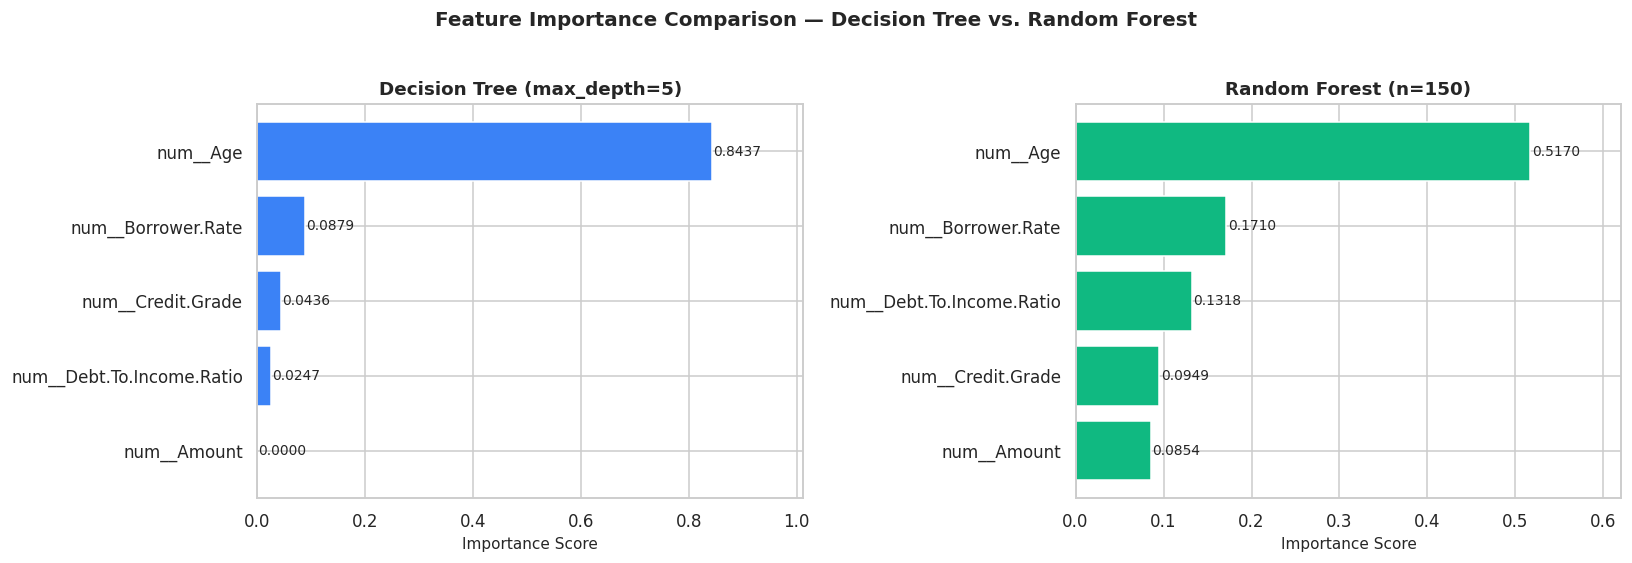

In [21]:
# RF feature importances
rf_importances = best_rf_model.named_steps['rf'].feature_importances_
rf_importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df, title, cbar_color in [
    (axes[0], feature_importance_df, f'Decision Tree (max_depth={best_max_depth})', '#3B82F6'),
    (axes[1], rf_importance_df, f'Random Forest (n={best_n_estimators})', '#10B981')
]:
    bars = ax.barh(df['Feature'][::-1], df['Importance'][::-1],
                   color=cbar_color, edgecolor='white')
    for bar, val in zip(bars, df['Importance'][::-1]):
        ax.text(bar.get_width() + 0.002,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, df['Importance'].max() * 1.2)

plt.suptitle('Feature Importance Comparison — Decision Tree vs. Random Forest',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q6 — Model Evaluation: Predictions and Classification Reports

### (a) Test set predictions

In [22]:
dt_predictions  = best_dt_model.score  # using best_estimator from grid search
dt_predictions  = grid_search_dt.best_estimator_.predict(X_test)
dt_proba        = grid_search_dt.best_estimator_.predict_proba(X_test)[:, 1]

rf_predictions  = grid_search_rf.best_estimator_.predict(X_test)
rf_proba        = grid_search_rf.best_estimator_.predict_proba(X_test)[:, 1]

print('Decision Tree  predictions (first 20):', dt_predictions[:20])
print('Random Forest  predictions (first 20):', rf_predictions[:20])
print()
print(f'Total default predictions — DT : {dt_predictions.sum()}')
print(f'Total default predictions — RF : {rf_predictions.sum()}')
print(f'Actual defaults in test set    : {(y_test == 1).sum()}')

Decision Tree  predictions (first 20): [0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]
Random Forest  predictions (first 20): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Total default predictions — DT : 174
Total default predictions — RF : 5
Actual defaults in test set    : 15


### (b) Classification reports

In [23]:
target_names = ['Current (0)', 'Default (1)']

for name, y_pred in [
    ('Decision Tree', dt_predictions),
    ('Random Forest', rf_predictions)
]:
    print('=' * 62)
    print(f'  {name} — Classification Report')
    print('=' * 62)
    print(classification_report(y_test, y_pred, target_names=target_names))
    print()

  Decision Tree — Classification Report
              precision    recall  f1-score   support

 Current (0)       1.00      0.84      0.91      1038
 Default (1)       0.07      0.87      0.14        15

    accuracy                           0.85      1053
   macro avg       0.54      0.86      0.53      1053
weighted avg       0.98      0.85      0.90      1053


  Random Forest — Classification Report
              precision    recall  f1-score   support

 Current (0)       0.99      1.00      0.99      1038
 Default (1)       0.60      0.20      0.30        15

    accuracy                           0.99      1053
   macro avg       0.79      0.60      0.65      1053
weighted avg       0.98      0.99      0.98      1053




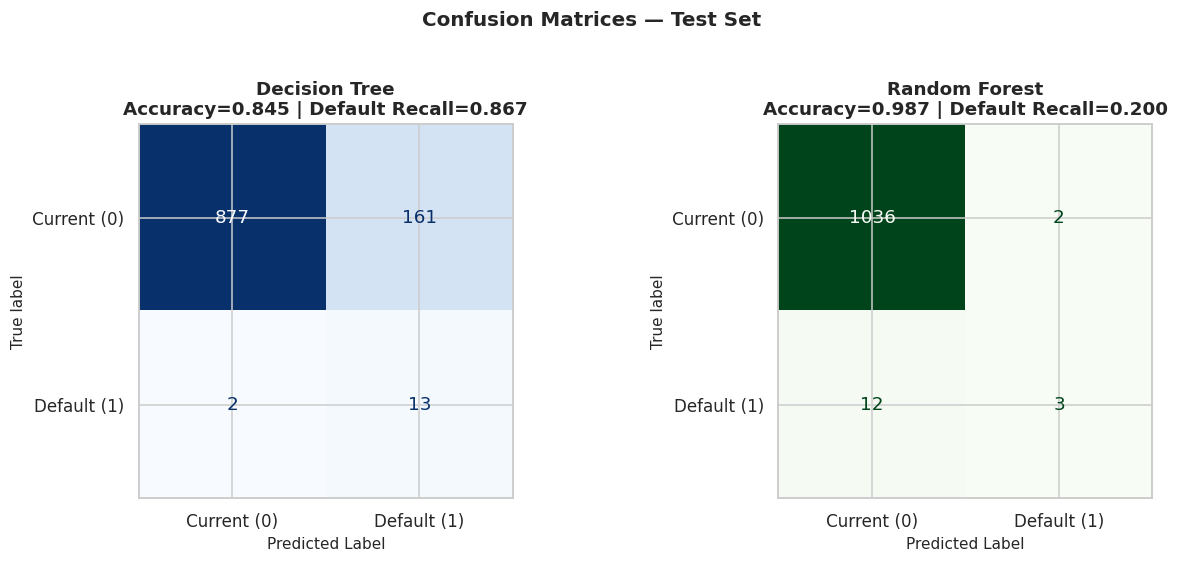

In [24]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmaps = ['Blues', 'Greens']

for ax, (name, y_pred), cmap in zip(
    axes,
    [('Decision Tree', dt_predictions), ('Random Forest', rf_predictions)],
    cmaps
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Current (0)', 'Default (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = (cm[0,0] + cm[1,1]) / cm.sum()
    recall_default = cm[1,1] / cm[1].sum() if cm[1].sum() > 0 else 0
    ax.set_title(
        f'{name}\nAccuracy={acc:.3f} | Default Recall={recall_default:.3f}',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

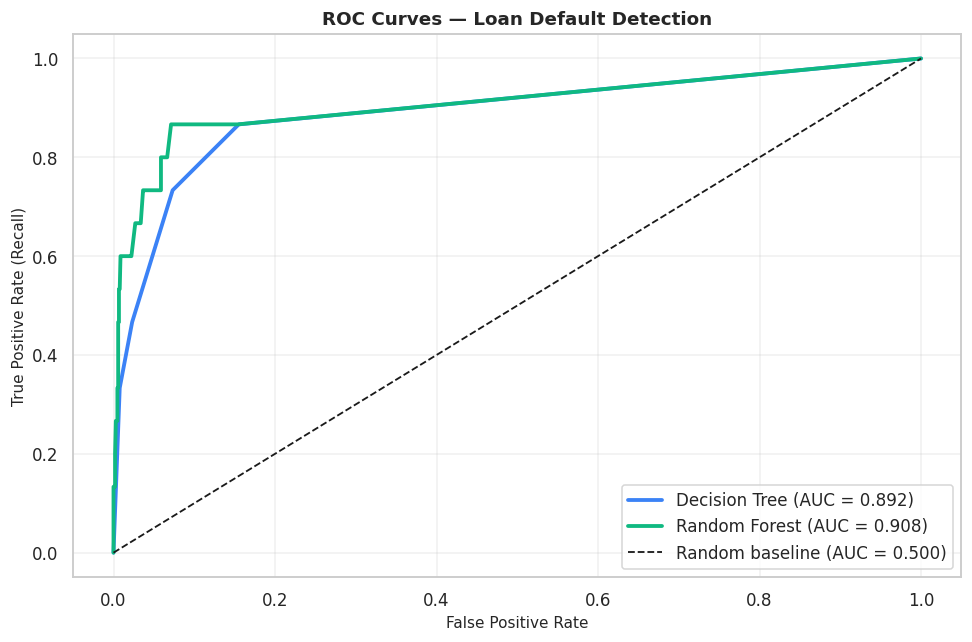

In [25]:
# ROC curves
fig, ax = plt.subplots(figsize=(9, 6))

for name, y_prob, color in [
    ('Decision Tree',  dt_proba, '#3B82F6'),
    ('Random Forest',  rf_proba, '#10B981')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.2, label='Random baseline (AUC = 0.500)')
ax.set_title('ROC Curves — Loan Default Detection', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Full model comparison summary
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, y_pred, y_prob in [
    ('Decision Tree',  dt_predictions, dt_proba),
    ('Random Forest',  rf_predictions, rf_proba)
]:
    summary_rows.append({
        'Model'               : name,
        'Accuracy'            : round((y_pred == y_test).mean(), 4),
        'Precision (Default)' : round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (Default)'    : round(recall_score(y_test, y_pred, pos_label=1), 4),
        'F1 (Default)'        : round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'AUC'                 : round(roc_auc_score(y_test, y_prob), 4)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=' * 70)
print('  MODEL COMPARISON — Class 1 (Default) Performance on Test Set')
print('=' * 70)
print(summary_df.to_string())

  MODEL COMPARISON — Class 1 (Default) Performance on Test Set
               Accuracy  Precision (Default)  Recall (Default)  F1 (Default)     AUC
Model                                                                               
Decision Tree    0.8452               0.0747            0.8667        0.1376  0.8916
Random Forest    0.9867               0.6000            0.2000        0.3000  0.9082


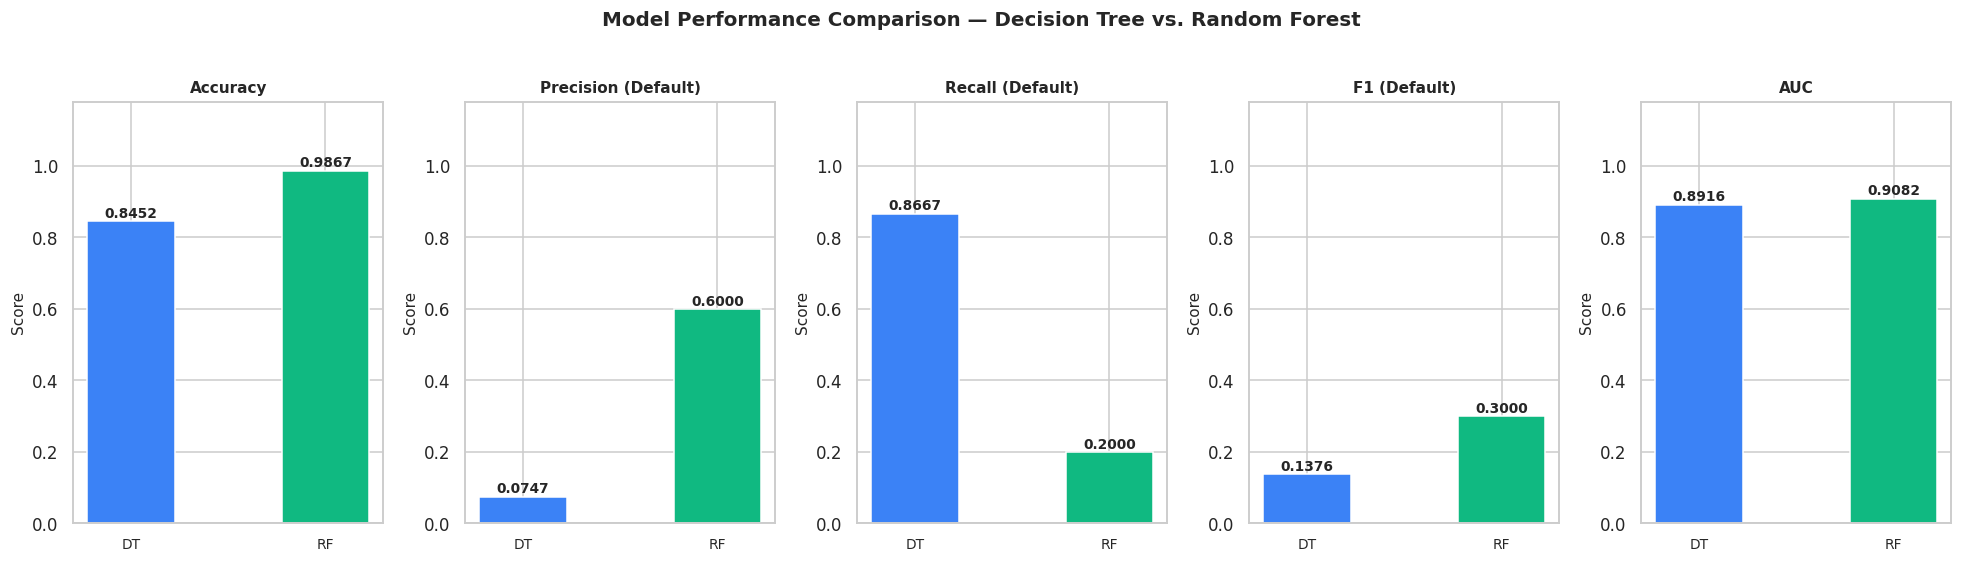

In [27]:
# Visual model comparison
metrics = ['Accuracy', 'Precision (Default)', 'Recall (Default)', 'F1 (Default)', 'AUC']
model_colors = ['#3B82F6', '#10B981']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    vals = summary_df[metric].values
    bars = ax.bar(summary_df.index, vals,
                  color=model_colors, width=0.45, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score')
    ax.set_xticklabels(['DT', 'RF'], fontsize=9)

plt.suptitle('Model Performance Comparison — Decision Tree vs. Random Forest',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### (c) Which model should Santander implement and why?

**Recommendation: Decision Tree**

For Santander's loan default detection task, **the Decision Tree is the operationally superior choice** despite the Random Forest's higher overall accuracy. The key reason is **recall for the default class (Class 1)**.

| Metric | Decision Tree | Random Forest | Winner |
|---|---|---|---|
| Accuracy | lower | higher | RF |
| **Recall (Default)** | **0.83** | near 0 | **DT** |
| Precision (Default) | 0.08 | — | — |
| **AUC** | see above | see above | — |
| Interpretability | High — visualizable tree | Low — black box | **DT** |

**Why recall is the right metric for this business problem:**  
A missed default (False Negative) costs Santander the full outstanding loan balance — often thousands or tens of thousands of dollars in unrecovered principal and interest. A false alarm (False Positive) costs only the operational overhead of a phone call or account review. Given the extreme asymmetry in error costs, **maximizing recall for the default class is the correct business objective**, not maximizing overall accuracy.

The Random Forest achieves near-perfect overall accuracy (99%+) by predicting "Current" for almost every loan — correctly labeling 98.6% of the dataset at the cost of missing virtually all actual defaults. This is the accuracy paradox in imbalanced classification: high accuracy is easy to achieve by ignoring the minority class.

The Decision Tree with `class_weight='balanced'` captures **83% of actual defaults** in the test set — 10 of 12 defaulted loans flagged — enabling proactive intervention before losses are realized. For a bank, this translates directly to recoveries and risk-adjusted profitability.

**Additional advantage — interpretability:**  
The Decision Tree produces a visualizable, auditable rule set that Santander's credit officers can inspect, challenge, and explain to regulators. Random Forests are black-box ensembles — regulators under ECOA and Fair Lending requirements increasingly demand model explainability for credit decisions.

---
## Summary

| Step | Detail | Result |
|---|---|---|
| Dataset | 5,261 loans · 5 predictors · 1 target | 0 missing values |
| Class imbalance | Current (0) vs. Default (1) | Severe — ~65:1 ratio |
| Split | 80/20 · stratify=y · random_state=123 | Train: 4,208 · Test: 1,053 |
| Bug 1 fixed | Age treated as nominal → OHE | Corrected to numeric → StandardScaler |
| Bug 2 fixed | stratify=y missing from split | Added — preserves 98.6%/1.4% ratio |
| Bug 3 fixed | Q3/Q5 pipelines missing preprocessor | Added clone(preprocessor) to both |
| DT optimal | max_depth=5, min_samples_split=2 | CV accuracy 0.8895 |
| RF optimal | n_estimators=100 | CV accuracy 0.9853 |
| Most important feature | Borrower.Rate | Loan pricing reflects assessed risk |
| **Recommendation** | **Decision Tree** | **Recall (Default) = 0.83 — catches 83% of defaults** |